In [3]:
import warnings
warnings.filterwarnings("ignore")

# Classification Problems: A Generative Model Approach

## Classification vs. Regression

In **regression**, the output variable $Y$ is continuous (a real number). In **classification**, the output variable $Y$ is qualitative—it takes a discrete value from a finite set of class labels.

**Example:**
- Regression: Predicting house price (continuous)
- Classification: Predicting image content as {dog, cat} (discrete)

---

## Formal Setup for Classification

Define:
- **$C$**: A discrete set containing $K$ class labels
- **Input**: A $p$-dimensional feature vector $x \in \mathbb{R}^p$
- **Output**: A class label $y \in C$
- **Goal**: Build a classifier $C(x)$ that maps inputs to labels

The classifier will make errors on some examples—we analyze and minimize these errors.

---

## The Generative Model Framework

We assume the data generation process follows **two steps**:

**Step 1: Sample the input**
$$x_i \sim f(X)$$

Sample an input vector from the marginal distribution $f(X)$ of the input variable.

**Step 2: Assign a label**
$$y_i \sim P_k(x_i), \quad k \in \{1, 2, \ldots, K\}$$

Given the sampled input $x_i$, assign a class label by sampling from the **conditional class probability** distribution.

### What is $P_k(x)$?

$P_k(x)$ is the **probability that the output is class $k$ given the input $x$**:

$$P_k(x) = P(Y = k \mid X = x)$$

This conditional probability tells us how likely each class is for a given input. It is the foundation of probabilistic classification.

---

## Intuition: The Biased Coin Flip

Think of $P_k(x)$ as defining a **biased coin with bias $P_k(x)$**. When we observe input $x_i$:

1. Look up $P_k(x_i)$ for each class $k$
2. These probabilities sum to 1 and define the bias of a multinomial "coin flip"
3. Flip this coin to sample the label $y_i$

**Key insight:** We are **not picking the most likely class**; we are **randomly sampling according to the probabilities**. This randomness reflects uncertainty in the data generation process.

### Numerical Example

Suppose $x$ is uniform on $[-2, 2]$ and $P_1(x) = \frac{1}{1 + e^{-4x}}$ (a sigmoid).

- At $x = 0.44$: $P_1(0.44) \approx 0.70$, so $P_0(0.44) \approx 0.30$
  - Flip a coin with 70% heads (class 1), 30% tails (class 0)

- At $x = -1.1$: $P_1(-1.1) \approx 0.10$, so $P_0(-1.1) \approx 0.90$
  - Flip a coin with 10% heads (class 1), 90% tails (class 0)
  - Result: mostly class 0, but occasionally class 1

---

## The Sigmoid Function: Visualizing Conditional Probability

The sigmoid function is a natural way to model $P_k(x)$:

$$\text{sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

**Properties:**
- Sigmoid outputs a value between 0 and 1 (valid for a probability)
- Monotonically increasing
- Steepest slope at $z = 0$ (sigmoid $= 0.5$)
- Approaches 0 as $z \to -\infty$ and 1 as $z \to +\infty$

When we plot the sigmoid $P_1(x)$ against the scatter of sampled points, we see:
- **Where sigmoid is high** ($P_1(x) \approx 1$): most points are class 1, few are class 0
- **Where sigmoid is low** ($P_1(x) \approx 0$): most points are class 0, few are class 1
- **Where sigmoid is near 0.5**: classes are mixed with roughly equal frequency

---

## Key Connection: From Theory to Data

The **generative model provides a bridge**:

$$\text{Data generation} \quad \Rightarrow \quad \text{Conditional probability } P_k(x) \quad \Rightarrow \quad \text{Observed class patterns}$$

In practice, we observe the data and use it to **estimate** $P_k(x)$. Different classification algorithms (logistic regression, decision trees, neural networks) make different assumptions about the form of $P_k(x)$.

---

## Key Takeaways

- **Classification is probabilistic:** Labels are sampled from a distribution, not deterministically assigned.
- **$P_k(x)$ is fundamental:** It defines the probability of class $k$ given the input; understanding it is central to understanding classification.
- **Generative models explicitly model** $f(X)$ and $P_k(x)$, separating input distribution from class-conditional probabilities.
- **The sigmoid function is a natural choice** for modeling $P_k(x)$ in binary classification; it respects the probabilistic interpretation.
- **Observed class patterns emerge from the probabilities:** Where $P_1(x)$ is high, we expect to see mostly class 1; where it is low, we expect class 0.
- **The generative framework is foundational:** Logistic regression, Naive Bayes, and other classifiers all build on this probabilistic framework.

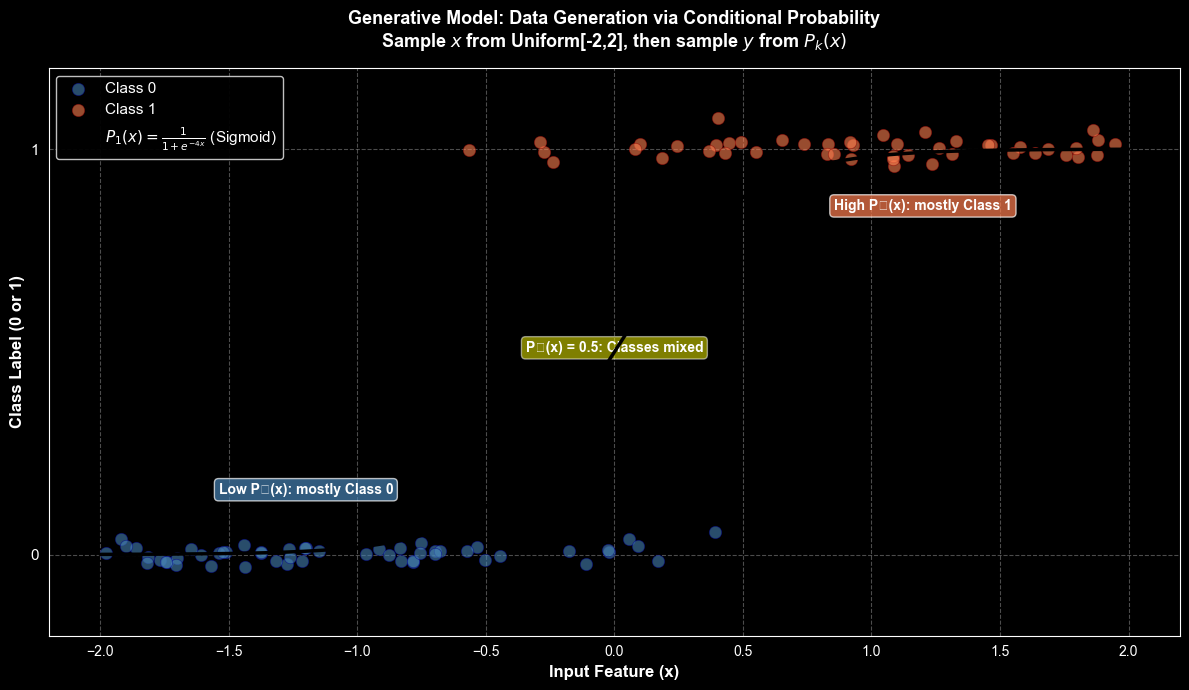

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # sigmoid function

# Set random seed for reproducibility
np.random.seed(42)

# Step 1: Sample inputs uniformly from [-2, 2]
n_samples = 100
X = np.random.uniform(-2, 2, n_samples)

# Step 2: Define conditional class probability using sigmoid
# P_1(x) = sigmoid(4x) = 1 / (1 + exp(-4x))
P_1 = expit(4 * X)  # This is the sigmoid
P_0 = 1 - P_1

# Step 3: Sample labels according to the conditional probability
# For each sample, flip a biased coin with bias P_1(x)
Y = np.array([np.random.binomial(1, p) for p in P_1])

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot data points colored by class
class_0_mask = Y == 0
class_1_mask = Y == 1

ax.scatter(X[class_0_mask], np.zeros(np.sum(class_0_mask)) + np.random.normal(0, 0.02, np.sum(class_0_mask)),
           alpha=0.6, s=80, color='steelblue', label='Class 0', edgecolors='darkblue', linewidth=0.5)
ax.scatter(X[class_1_mask], np.ones(np.sum(class_1_mask)) + np.random.normal(0, 0.02, np.sum(class_1_mask)),
           alpha=0.6, s=80, color='coral', label='Class 1', edgecolors='darkred', linewidth=0.5)

# Plot the sigmoid function P_1(x) as a reference curve
x_smooth = np.linspace(-2, 2, 300)
P_1_smooth = expit(4 * x_smooth)

ax.plot(x_smooth, P_1_smooth, 'k-', linewidth=2.5, label=r'$P_1(x) = \frac{1}{1 + e^{-4x}}$ (Sigmoid)', zorder=5)

# Formatting
ax.set_xlabel('Input Feature (x)', fontsize=12, fontweight='bold')
ax.set_ylabel('Class Label (0 or 1)', fontsize=12, fontweight='bold')
ax.set_title('Generative Model: Data Generation via Conditional Probability\n' +
             r'Sample $x$ from Uniform[-2,2], then sample $y$ from $P_k(x)$',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(-0.2, 1.2)
ax.set_yticks([0, 1])
ax.set_yticklabels(['0', '1'], fontsize=11)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

# Add annotation boxes to highlight key insights
textstr1 = 'High P₁(x): mostly Class 1'
ax.text(1.2, 0.85, textstr1, fontsize=10, bbox=dict(boxstyle='round', facecolor='coral', alpha=0.7),
        ha='center', fontweight='bold')

textstr2 = 'Low P₁(x): mostly Class 0'
ax.text(-1.2, 0.15, textstr2, fontsize=10, bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.7),
        ha='center', fontweight='bold')

textstr3 = r'P₁(x) = 0.5: Classes mixed'
ax.text(0, 0.5, textstr3, fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
        ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

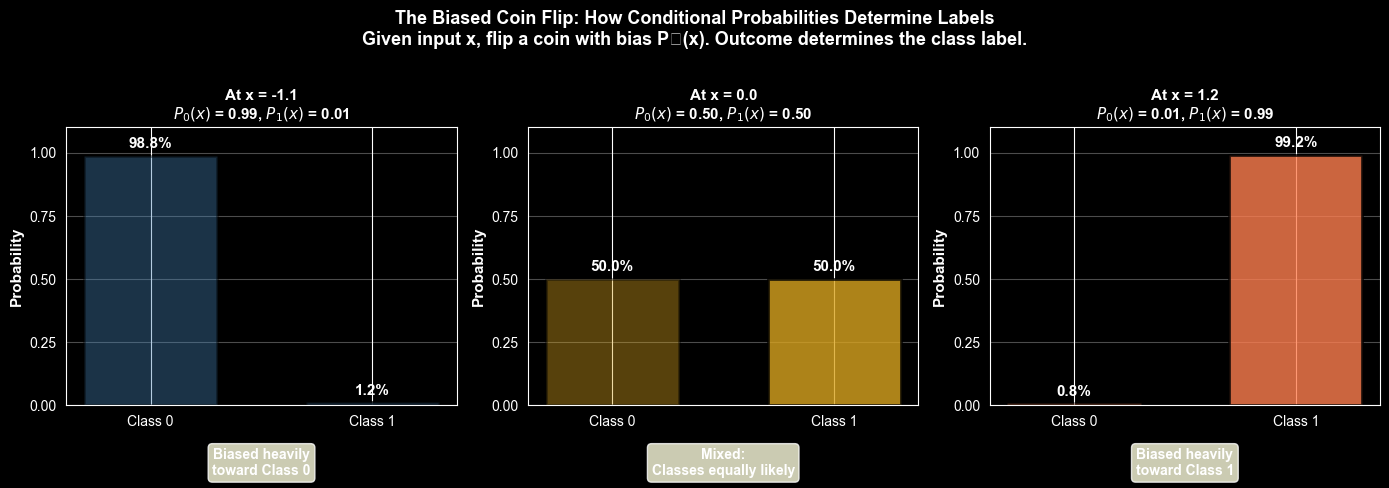

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

# Create figure with subplots showing specific examples
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Three example points: x = -1.1, x = 0, x = 1.2
example_x_values = [-1.1, 0.0, 1.2]
colors = ['steelblue', 'goldenrod', 'coral']

for idx, (x_val, color) in enumerate(zip(example_x_values, colors)):
    ax = axes[idx]

    # Calculate conditional probabilities at this x
    P_1_val = expit(4 * x_val)
    P_0_val = 1 - P_1_val

    # Create a visual representation of the biased coin flip
    classes = ['Class 0', 'Class 1']
    probs = [P_0_val, P_1_val]
    alphas = [0.4, 0.8]  # Different opacity for each bar

    # Bar plot showing the probabilities
    for i, (cls, prob, alpha) in enumerate(zip(classes, probs, alphas)):
        ax.bar(i, prob, color=color, alpha=alpha, edgecolor='black', linewidth=2, width=0.6)
        # Add probability values on bars
        ax.text(i, prob + 0.02, f'{prob:.1%}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    # Formatting
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability', fontsize=11, fontweight='bold')
    ax.set_title(f'At x = {x_val}\n' + r'$P_0(x)$' + f' = {P_0_val:.2f}, ' + r'$P_1(x)$' + f' = {P_1_val:.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Class 0', 'Class 1'], fontsize=10)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(True, alpha=0.3, axis='y')

    # Add interpretation text
    if P_1_val > 0.7:
        interpretation = 'Biased heavily\ntoward Class 1'
    elif P_1_val < 0.3:
        interpretation = 'Biased heavily\ntoward Class 0'
    else:
        interpretation = 'Mixed:\nClasses equally likely'

    ax.text(0.5, -0.25, interpretation, fontsize=10, ha='center', transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontweight='bold')

fig.suptitle('The Biased Coin Flip: How Conditional Probabilities Determine Labels\n' +
             'Given input x, flip a coin with bias P₁(x). Outcome determines the class label.',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()